In [9]:
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("leo085/MoCA-Long-iWatch-FT/cdvp4abb")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_random_hip = pd.DataFrame(rows)

print(chap_random_hip.shape)   # should now be full length, not capped at 500
# chap_random_hip = chap_random_hip[["_step", "perf/bal_acc", "perf/test_loss"]]

(12921, 16)


In [10]:
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("/leo085/MoCA-Long-iWatch-FT/runs/p5or8b5t")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_ft_hip = pd.DataFrame(rows)

print(chap_ft_hip.shape)   # should now be full length, not capped at 500
# chap_ft_hip = chap_ft_hip[["_step", "perf/bal_acc", "perf/test_loss"]]

(12921, 16)


In [11]:
import matplotlib.pyplot as plt
import os

def plot_chap_nature(df_ft, df_random,
                     label_ft="CHAP Fine-Tuned",
                     label_random="CHAP Random Init",
                     save_path='figures'):
    """
    Nature-style plot for CHAP models with epoch inferred from row index.
    Assumes 40 valid epochs in both fine-tuned and randomly initialized runs.
    """

    # Filter and index
    df_ft = df_ft[["perf/bal_acc", "perf/test_loss"]].dropna().reset_index(drop=True)
    df_random = df_random[["perf/bal_acc", "perf/test_loss"]].dropna().reset_index(drop=True)

    df_ft["epoch"] = range(len(df_ft))
    df_random["epoch"] = range(len(df_random))

    assert len(df_ft) == len(df_random) == 40, "Expected 40 epochs per run"

    # Nature-style font and line settings
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
        "font.size": 9,
        "axes.labelsize": 9,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.5,
        "lines.linewidth": 1.0,
        "legend.frameon": False,
        "savefig.dpi": 600
    })

    fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))  # ~178mm × 81mm

    color_ft = "#0072B2"
    color_random = "#D55E00"

    # Plot panel a: Balanced Accuracy
    axes[0].plot(df_random["epoch"], df_random["perf/bal_acc"],
                 label=label_random, color=color_random)
    axes[0].plot(df_ft["epoch"], df_ft["perf/bal_acc"],
                 label=label_ft, color=color_ft)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Validation Balanced Accuracy")
    axes[0].text(-0.12, 1.05, "a", transform=axes[0].transAxes,
                 fontsize=10, fontweight='bold', va='top', ha='right')

    # Plot panel b: Test Loss
    axes[1].plot(df_random["epoch"], df_random["perf/test_loss"],
                 label=label_random, color=color_random)
    axes[1].plot(df_ft["epoch"], df_ft["perf/test_loss"],
                 label=label_ft, color=color_ft)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Validation Loss")
    axes[1].text(-0.12, 1.05, "b", transform=axes[1].transAxes,
                 fontsize=10, fontweight='bold', va='top', ha='right')

    # Clean axes
    for ax in axes:
        ax.tick_params(direction="out", length=3, width=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(False)

    # Place legend inside panel b, top left
    axes[1].legend(loc="upper right", frameon=False, handlelength=1.5)

    plt.tight_layout(w_pad=2)

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, format="pdf", bbox_inches="tight", transparent=True)
    else:
        plt.show()


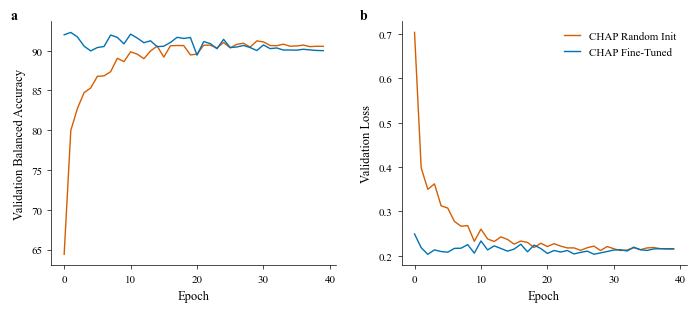

In [12]:
plot_chap_nature(chap_ft_hip, chap_random_hip,save_path='figures/chap_hip_plot.pdf')

In [13]:
# 
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("/leo085/MoCA-Long-iWatch-FT/runs/7zd1josa")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_random_wrist = pd.DataFrame(rows)


chap_random_wrist = pd.DataFrame(rows)

print(chap_random_wrist.shape)   # should now be full length, not capped at 500
# chap_random_wrist = chap_random_wrist[["_step", "perf/bal_acc", "perf/test_loss"]]

(13321, 16)


In [14]:

# 
import wandb
import pandas as pd

api = wandb.Api()
run = api.run("/leo085/MoCA-Long-iWatch-FT/runs/kmcfojlc")

# Use scan_history to fetch all steps
rows = []
for row in run.scan_history():
    rows.append(row)

chap_ft_wrist = pd.DataFrame(rows)


chap_ft_wrist = pd.DataFrame(rows)

print(chap_ft_wrist.shape)   # should now be full length, not capped at 500
# chap_ft_wrist = chap_ft_wrist[["_step", "perf/bal_acc", "perf/test_loss"]]

(13321, 16)


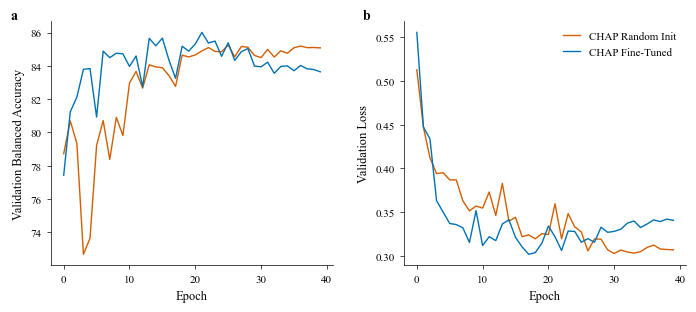

In [15]:
plot_chap_nature(chap_ft_wrist, chap_random_wrist,save_path='figures/chap_wrist_plot.pdf')

# Limited Label

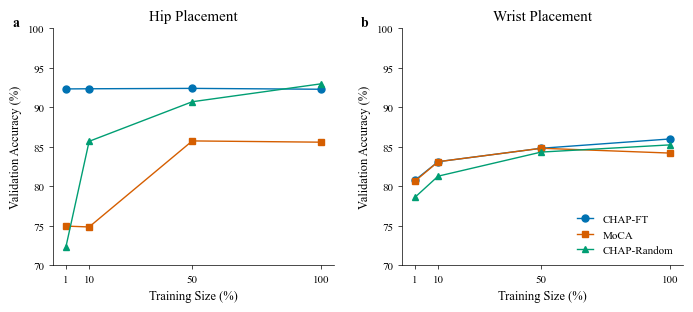

In [8]:
import matplotlib.pyplot as plt
import os

# Nature-style font and line settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "legend.frameon": False,
    "savefig.dpi": 600
})

# Training sizes
train_sizes = [1, 10, 50, 100]

# Validation accuracy for each model and placement
chap_ft_hip = [92.33, 92.35, 92.40, 92.29]
moca_hip = [74.97, 74.86, 85.75, 85.59]
chap_random_hip = [72.34, 85.70, 90.71, 92.98]

chap_ft_wrist = [80.77, 83.12, 84.82, 86.00]
moca_wrist = [80.65, 83.12, 84.82, 84.21]
chap_random_wrist = [78.61, 81.29, 84.34, 85.25]

# Define colors
color_chap = "#0072B2"
color_moca = "#D55E00"
color_random = "#009E73"

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(7.0, 3.2))  # ~178mm × 81mm

# HIP Plot
axes[0].plot(train_sizes, chap_ft_hip, marker='o', label="CHAP-FT", color=color_chap, markersize=5)
axes[0].plot(train_sizes, moca_hip, marker='s', label="MoCA", color=color_moca, markersize=5)
axes[0].plot(train_sizes, chap_random_hip, marker='^', label="CHAP-Random", color=color_random, markersize=5)

axes[0].set_xlabel("Training Size (%)")
axes[0].set_ylabel("Validation Accuracy (%)")
axes[0].set_title("Hip Placement")
axes[0].set_ylim(70, 100)
axes[0].set_xticks(train_sizes)  # Only show ticks at training sizes
axes[0].tick_params(direction="out", length=3, width=0.5)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(False)
axes[0].text(-0.12, 1.05, "a", transform=axes[0].transAxes,
             fontsize=10, fontweight='bold', va='top', ha='right')

# WRIST Plot
axes[1].plot(train_sizes, chap_ft_wrist, marker='o', label="CHAP-FT", color=color_chap, markersize=5)
axes[1].plot(train_sizes, moca_wrist, marker='s', label="MoCA", color=color_moca, markersize=5)
axes[1].plot(train_sizes, chap_random_wrist, marker='^', label="CHAP-Random", color=color_random, markersize=5)

axes[1].set_xlabel("Training Size (%)")
axes[1].set_ylabel("Validation Accuracy (%)")
axes[1].set_title("Wrist Placement")
axes[1].set_ylim(70, 100)
axes[1].set_xticks(train_sizes)  # Only show ticks at training sizes
axes[1].tick_params(direction="out", length=3, width=0.5)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(False)
axes[1].text(-0.12, 1.05, "b", transform=axes[1].transAxes,
             fontsize=10, fontweight='bold', va='top', ha='right')

# Legend inside second panel
axes[1].legend(loc="lower right", frameon=False, handlelength=1.5)

# Final layout and save
plt.tight_layout(w_pad=2)
save_path = "figures/chap_moca_accuracy_curve.pdf"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, format="pdf", bbox_inches="tight", transparent=True)
plt.show()


# Data distribution

### hip

In [1]:
import h5py
import numpy as np
from tqdm import tqdm

data_path = '/niddk-data-central/iWatch/pre_processed_long_seg/H/10s_train.h5'
save_mean_path = 'hip_mean.npy'
save_std_path = 'hip_std.npy'
save_label_path = 'hip_labels.npy'
batch_size = 1000  # Tune based on available RAM

with h5py.File(data_path, 'r') as f:
    dset = f['x']   # shape: (41264, 42, 100, 3)
    labels = f['y'] # shape: (41264, 42)

    num_samples, num_channels, window_len, num_axes = dset.shape
    assert (window_len, num_axes) == (100, 3)

    # Preallocate arrays
    hip_mean = np.zeros((num_samples, num_channels), dtype=np.float32)
    hip_std = np.zeros((num_samples, num_channels), dtype=np.float32)
    hip_labels = np.zeros((num_samples, num_channels), dtype=labels.dtype)

    # Process in batches
    for start in tqdm(range(0, num_samples, batch_size), desc='Processing'):
        end = min(start + batch_size, num_samples)
        x_batch = dset[start:end]  # shape: (B, 42, 100, 3)

        # Mean and std over time (axis=2), then average across axes (axis=-1)
        mean_per_channel = np.mean(x_batch, axis=2)  # (B, 42, 3)
        std_per_channel = np.std(x_batch, axis=2)    # (B, 42, 3)

        hip_mean[start:end] = np.mean(mean_per_channel, axis=-1)
        hip_std[start:end] = np.mean(std_per_channel, axis=-1)

        # Labels: direct slice copy
        hip_labels[start:end] = labels[start:end]

# Save outputs
np.save(save_mean_path, hip_mean)
np.save(save_std_path, hip_std)
np.save(save_label_path, hip_labels)

print(f"✅ Done. Saved mean to {save_mean_path}, std to {save_std_path}, labels to {save_label_path}")


Processing: 100%|██████████| 42/42 [00:46<00:00,  1.10s/it]


✅ Done. Saved mean to hip_mean.npy, std to hip_std.npy, labels to hip_labels.npy


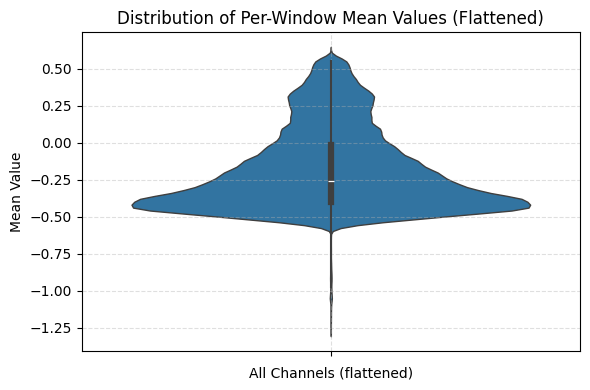

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
# wrist_mean.npy'
hip_mean_path = 'hip_mean.npy'
hip_mean = np.load(hip_mean_path)  # shape: (41264, 42)

# Flatten to 1D
flat_values = hip_mean.flatten()  # shape: (41264 * 42,)

# Plot violin plot
plt.figure(figsize=(6, 4))
sns.violinplot(y=flat_values, linewidth=1)

plt.title('Distribution of Per-Window Mean Values (Flattened)')
plt.ylabel('Mean Value')
plt.xlabel('All Channels (flattened)')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


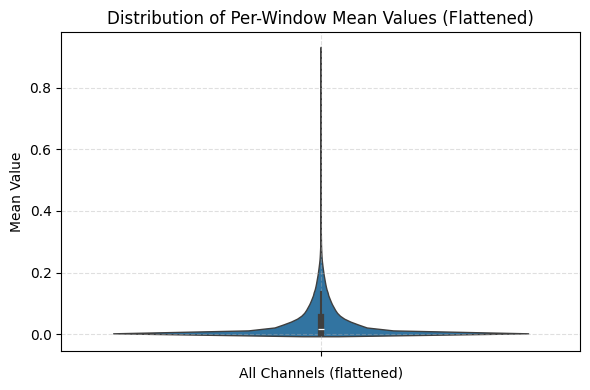

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load data
hip_std_path = 'hip_std.npy'
hip_std = np.load(hip_std_path)  # shape: (41264, 42)

# Flatten to 1D
flat_values = hip_std.flatten()  # shape: (41264 * 42,)

# Plot violin plot
plt.figure(figsize=(6, 4))
sns.violinplot(y=flat_values, linewidth=1)

plt.title('Distribution of Per-Window Mean Values (Flattened)')
plt.ylabel('Mean Value')
plt.xlabel('All Channels (flattened)')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


### wrist

In [3]:
import h5py
import numpy as np
from tqdm import tqdm

data_path = '/niddk-data-central/iWatch/pre_processed_long_seg/W/10s_train.h5'
save_mean_path = 'wrist_mean.npy'
save_std_path = 'wrist_std.npy'
save_label_path = 'wrist_labels.npy'
batch_size = 1000  # Tune based on available RAM

with h5py.File(data_path, 'r') as f:
    dset = f['x']   # shape: (41264, 42, 100, 3)
    labels = f['y'] # shape: (41264, 42)

    num_samples, num_channels, window_len, num_axes = dset.shape
    assert (window_len, num_axes) == (100, 3)

    # Preallocate output arrays
    wrist_mean = np.zeros((num_samples, num_channels), dtype=np.float32)
    wrist_std = np.zeros((num_samples, num_channels), dtype=np.float32)
    wrist_labels = np.zeros((num_samples, num_channels), dtype=labels.dtype)

    # Process in batches
    for start in tqdm(range(0, num_samples, batch_size), desc='Processing'):
        end = min(start + batch_size, num_samples)
        x_batch = dset[start:end]  # shape: (B, 42, 100, 3)

        # Mean/std over time (axis=2), then average across axes (axis=-1)
        mean_per_channel = np.mean(x_batch, axis=2)  # shape: (B, 42, 3)
        std_per_channel = np.std(x_batch, axis=2)    # shape: (B, 42, 3)

        wrist_mean[start:end] = np.mean(mean_per_channel, axis=-1)
        wrist_std[start:end] = np.mean(std_per_channel, axis=-1)

        # Copy labels
        wrist_labels[start:end] = labels[start:end]

# Save to disk
np.save(save_mean_path, wrist_mean)
np.save(save_std_path, wrist_std)
np.save(save_label_path, wrist_labels)

print(f"✅ Done. Saved mean to {save_mean_path}, std to {save_std_path}, labels to {save_label_path}")


Processing: 100%|██████████| 43/43 [00:46<00:00,  1.08s/it]

✅ Done. Saved mean to wrist_mean.npy, std to wrist_std.npy, labels to wrist_labels.npy


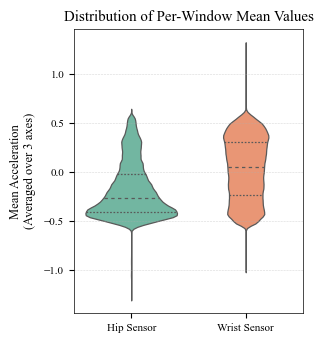

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
hip_mean = np.load('hip_mean.npy')     # shape: (N_hip, 42)
wrist_mean = np.load('wrist_mean.npy') # shape: (N_wrist, 42)

# Flatten to 1D
hip_flat = hip_mean.flatten()
wrist_flat = wrist_mean.flatten()

# Combine into dataframe-like format
data = [hip_flat, wrist_flat]
labels = ['Hip Sensor', 'Wrist Sensor']

# Set style for medical journal
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "legend.frameon": False
})

# Create figure
plt.figure(figsize=(3.2, 3.5))  # ~8.1 cm × 8.9 cm

# Colorful violin plot
sns.violinplot(data=data, linewidth=0.9, palette='Set2', inner='quartile')

# Labels and layout
plt.xticks([0, 1], labels)
plt.ylabel('Mean Acceleration\n(Averaged over 3 axes)', labelpad=6)
plt.xlabel('')
plt.title('Distribution of Per-Window Mean Values', pad=6)
plt.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)

# Save as high-resolution PDF
plt.tight_layout()
plt.savefig("mean_distribution_violin.pdf", format='pdf', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


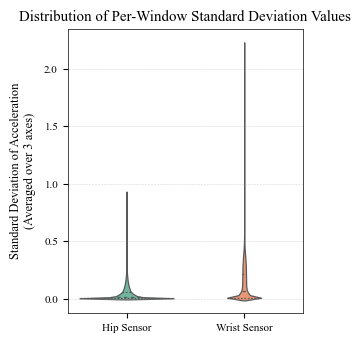

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
hip_std = np.load('hip_std.npy')     # shape: (N_hip, 42)
wrist_std = np.load('wrist_std.npy') # shape: (N_wrist, 42)

# Flatten to 1D
hip_flat = hip_std.flatten()
wrist_flat = wrist_std.flatten()

# Combine into dataframe-like format
data = [hip_flat, wrist_flat]
labels = ['Hip Sensor', 'Wrist Sensor']

# Set style for medical journal
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "legend.frameon": False
})

# Create figure
plt.figure(figsize=(3.2, 3.5))  # ~8.1 cm × 8.9 cm

# Colorful violin plot
sns.violinplot(data=data, linewidth=0.9, palette='Set2', inner='quartile')

# Labels and layout
plt.xticks([0, 1], labels)
plt.ylabel('Standard Deviation of Acceleration\n(Averaged over 3 axes)', labelpad=6)
plt.xlabel('')
plt.title('Distribution of Per-Window Standard Deviation Values', pad=6)
plt.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)

# Save as high-resolution PDF
plt.tight_layout()
plt.savefig("std_distribution_violin.pdf", format='pdf', dpi=600, bbox_inches='tight')

# Show the plot
plt.show()


/var/folders/yd/zz3pvt3n3yb2gz0g6xjn68th0000gn/T/ipykernel_84493/747704786.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar and title


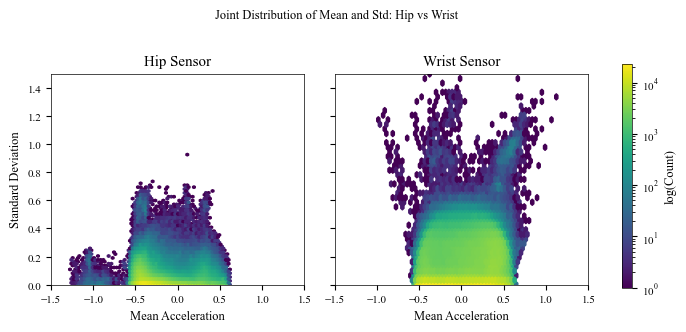

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
hip_mean = np.load('hip_mean.npy').flatten()
hip_std = np.load('hip_std.npy').flatten()
wrist_mean = np.load('wrist_mean.npy').flatten()
wrist_std = np.load('wrist_std.npy').flatten()

# TODO: Now I have hip_labels.npy and wrist_labels.npy, how can I overlaid it on the hexbin plot to indicates which distribution that each label probably lies in.
#  
# Journal-style settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
})

# Define consistent limits
xlim = [-1.5, 1.5]
ylim = [0.0, 1.5]

# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(6.8, 3.2), sharex=True, sharey=True)

# HIP sensor
hb1 = axs[0].hexbin(
    hip_mean, hip_std,
    gridsize=60,
    cmap='viridis',
    bins='log'
)
axs[0].set_title("Hip Sensor")
axs[0].set_xlabel("Mean Acceleration")
axs[0].set_ylabel("Standard Deviation")
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)

# WRIST sensor
hb2 = axs[1].hexbin(
    wrist_mean, wrist_std,
    gridsize=60,
    cmap='viridis',
    bins='log'
)
axs[1].set_title("Wrist Sensor")
axs[1].set_xlabel("Mean Acceleration")
axs[1].set_xlim(xlim)
axs[1].set_ylim(ylim)

# Add shared colorbar (better placement)
cb_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(hb2, cax=cb_ax)
cbar.set_label('log(Count)')

# Add suptitle with better spacing
fig.suptitle("Joint Distribution of Mean and Std: Hip vs Wrist", fontsize=9, y=1.02)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar and title

plt.savefig("joint_hexbin_hip_wrist.pdf", dpi=600, bbox_inches='tight')
plt.show()

/var/folders/yd/zz3pvt3n3yb2gz0g6xjn68th0000gn/T/ipykernel_34320/1143527799.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar + legend


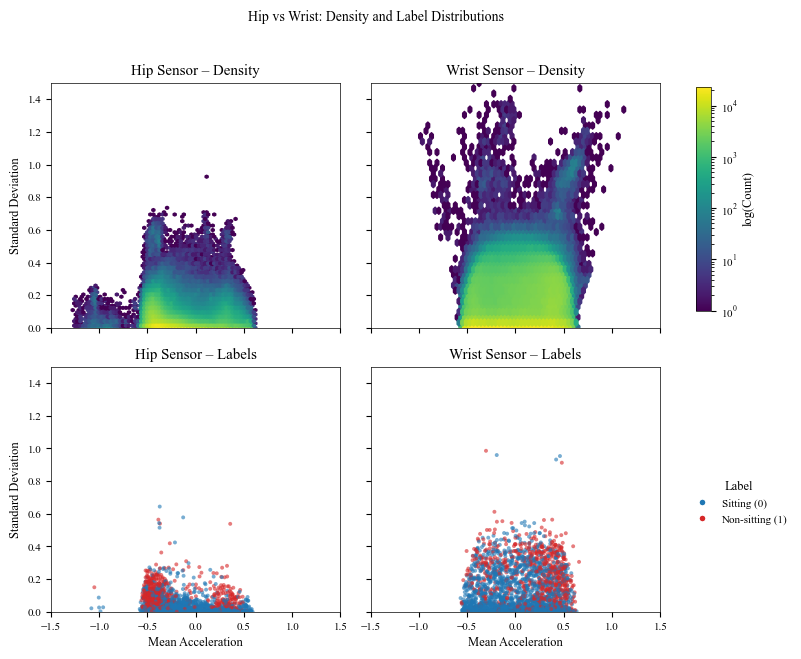

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

# Load data (flattened so labels match 1-to-1 with mean/std)
hip_mean = np.load('assest/backup/hip_mean.npy').flatten()
hip_std = np.load('assest/backup/hip_std.npy').flatten()
wrist_mean = np.load('assest/backup/wrist_mean.npy').flatten()
wrist_std = np.load('assest/backup/wrist_std.npy').flatten()
hip_labels = np.load('assest/backup/hip_labels.npy').flatten()
wrist_labels = np.load('assest/backup/wrist_labels.npy').flatten()

# Custom colormap: 0 -> blue (sitting), 1 -> red (non-sitting)
label_cmap = ListedColormap(["#1f77b4", "#d62728"])

# Journal-style settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "savefig.dpi": 600
})

# Consistent axis ranges
xlim = [-1.5, 1.5]
ylim = [0.0, 1.5]

# Figure with 2 rows (hexbin + scatter) and 2 columns (hip + wrist)
fig, axs = plt.subplots(2, 2, figsize=(7.6, 6.4), sharex=True, sharey=True)

# === HIP HEXBIN ===
hb1 = axs[0, 0].hexbin(
    hip_mean, hip_std,
    gridsize=60, cmap="viridis", bins="log"
)
axs[0, 0].set_title("Hip Sensor – Density")
axs[0, 0].set_xlim(xlim)
axs[0, 0].set_ylim(ylim)
axs[0, 0].set_ylabel("Standard Deviation")

# === HIP LABELS ===
sample_idx = np.random.choice(len(hip_mean), size=3000, replace=False)
axs[1, 0].scatter(
    hip_mean[sample_idx],
    hip_std[sample_idx],
    c=hip_labels[sample_idx],
    cmap=label_cmap,
    alpha=0.6,
    s=8,
    edgecolor="none"
)
axs[1, 0].set_title("Hip Sensor – Labels")
axs[1, 0].set_xlim(xlim)
axs[1, 0].set_ylim(ylim)
axs[1, 0].set_xlabel("Mean Acceleration")
axs[1, 0].set_ylabel("Standard Deviation")

# === WRIST HEXBIN ===
hb2 = axs[0, 1].hexbin(
    wrist_mean, wrist_std,
    gridsize=60, cmap="viridis", bins="log"
)
axs[0, 1].set_title("Wrist Sensor – Density")
axs[0, 1].set_xlim(xlim)
axs[0, 1].set_ylim(ylim)

# === WRIST LABELS ===
sample_idx = np.random.choice(len(wrist_mean), size=3000, replace=False)
axs[1, 1].scatter(
    wrist_mean[sample_idx],
    wrist_std[sample_idx],
    c=wrist_labels[sample_idx],
    cmap=label_cmap,
    alpha=0.6,
    s=8,
    edgecolor="none"
)
axs[1, 1].set_title("Wrist Sensor – Labels")
axs[1, 1].set_xlim(xlim)
axs[1, 1].set_ylim(ylim)
axs[1, 1].set_xlabel("Mean Acceleration")

# === Shared colorbar for density (top-right outside) ===
cb_ax = fig.add_axes([0.92, 0.55, 0.02, 0.35])
cbar = fig.colorbar(hb2, cax=cb_ax)
cbar.set_label("log(Count)")

# === Custom legend (below colorbar, completely outside plot) ===
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Sitting (0)",
           markerfacecolor="#1f77b4", markersize=5),
    Line2D([0], [0], marker="o", color="w", label="Non-sitting (1)",
           markerfacecolor="#d62728", markersize=5)
]
fig.legend(
    handles=legend_elements,
    title="Label",
    loc="center left",
    bbox_to_anchor=(0.90, 0.25),  # position under colorbar
    frameon=False
)

fig.suptitle("Hip vs Wrist: Density and Label Distributions", fontsize=10, y=1.02)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar + legend
plt.savefig("hip_wrist_density_labels_outside.pdf", dpi=600, bbox_inches="tight")
plt.show()


Hip Sensor – Accuracy: 0.793, Balanced Acc: 0.659
Wrist Sensor – Accuracy: 0.767, Balanced Acc: 0.622


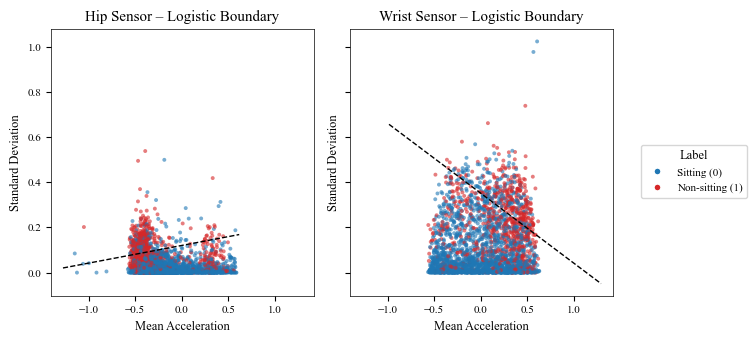

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Load data (flattened so labels match 1-to-1 with mean/std)
hip_mean = np.load('assest/backup/hip_mean.npy').flatten()
hip_std = np.load('assest/backup/hip_std.npy').flatten()
hip_labels = np.load('assest/backup/hip_labels.npy').flatten()

wrist_mean = np.load('assest/backup/wrist_mean.npy').flatten()
wrist_std = np.load('assest/backup/wrist_std.npy').flatten()
wrist_labels = np.load('assest/backup/wrist_labels.npy').flatten()

def fit_and_plot(mean, std, labels, sensor_name, ax, cmap=["#1f77b4", "#d62728"]):
    """Fit logistic regression and plot decision boundary."""
    X = np.vstack([mean, std]).T
    y = labels

    # Fit logistic regression
    clf = LogisticRegression().fit(X, y)

    # Evaluate
    y_pred = clf.predict(X)
    acc = accuracy_score(y, y_pred)
    bal_acc = balanced_accuracy_score(y, y_pred)
    print(f"{sensor_name} – Accuracy: {acc:.3f}, Balanced Acc: {bal_acc:.3f}")

    # Plot scatter
    sample_idx = np.random.choice(len(mean), size=3000, replace=False)
    sc = ax.scatter(mean[sample_idx], std[sample_idx], c=y[sample_idx],
                    cmap=plt.matplotlib.colors.ListedColormap(cmap),
                    s=8, alpha=0.6, edgecolor="none")

    # Plot decision boundary (line: w0 + w1*mean + w2*std = 0)
    x_vals = np.linspace(mean.min(), mean.max(), 200)
    y_vals = -(clf.intercept_[0] + clf.coef_[0,0]*x_vals) / clf.coef_[0,1]
    ax.plot(x_vals, y_vals, "k--", linewidth=1)

    ax.set_title(f"{sensor_name} – Logistic Boundary")
    ax.set_xlabel("Mean Acceleration")
    ax.set_ylabel("Standard Deviation")
    return sc

# Make figure
fig, axs = plt.subplots(1, 2, figsize=(7, 3.5), sharex=True, sharey=True)

sc1 = fit_and_plot(hip_mean, hip_std, hip_labels, "Hip Sensor", axs[0])
sc2 = fit_and_plot(wrist_mean, wrist_std, wrist_labels, "Wrist Sensor", axs[1])

# Legend (dot style)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Sitting (0)",
           markerfacecolor="#1f77b4", markersize=5),
    Line2D([0], [0], marker="o", color="w", label="Non-sitting (1)",
           markerfacecolor="#d62728", markersize=5)
]
fig.legend(handles=legend_elements, title="Label",
           loc="center right", bbox_to_anchor=(1.08, 0.5))

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("hip_wrist_logistic_boundary.pdf", dpi=600, bbox_inches="tight")
plt.show()


In [8]:
wrist_labels.sum(),len(wrist_labels)

(467112, 1785840)

In [3]:
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import jensenshannon

# Make 2D histograms
bins = 100
H_hip, _, _ = np.histogram2d(hip_mean, hip_std, bins=bins, density=True)
H_wrist, _, _ = np.histogram2d(wrist_mean, wrist_std, bins=bins, density=True)

# Flatten and normalize
P = H_hip.flatten()
Q = H_wrist.flatten()
P /= P.sum()
Q /= Q.sum()

# Jensen-Shannon Distance (symmetric, bounded [0,1])
js_dist = jensenshannon(P, Q)
print(f"Jensen-Shannon Distance = {js_dist:.3f}")


Jensen-Shannon Distance = 0.486


calculate number of parameters

In [4]:
import torch
from models_mae import MaskedAutoencoderViT, ClassiferHeadWrapper

# Initialize model
base_model = MaskedAutoencoderViT(
    img_size=[3, 4200],
    patch_size=[3, 100],
    patch_emb=True,
    use_rope=False,
    embed_dim=768,
    depth=12,
    num_heads=12
)

model = ClassiferHeadWrapper(base_model, num_classes=2)

# Define decoder submodule keys
decoder_keys = ["decoder_embed", "decoder_blocks", "decoder_norm", "decoder_pred"]

# Check if a parameter belongs to decoder
def is_not_decoder_param(name):
    return not any([name.startswith(f"backbone.{k}") for k in decoder_keys])

# Count all trainable parameters
total_all = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count trainable parameters excluding decoder
total_excl_decoder = sum(
    p.numel() for name, p in model.named_parameters()
    if p.requires_grad and is_not_decoder_param(name)
)

# Report
print(f"Total trainable parameters: {total_all:,} ({total_all / 1e6:.2f} M)")
print(f"Excluding decoder:           {total_excl_decoder:,} ({total_excl_decoder / 1e6:.2f} M)")
print(f"Decoder only:                {total_all - total_excl_decoder:,} ({(total_all - total_excl_decoder) / 1e6:.2f} M)")

# Optional: inspect model structure
# print(model)


number of patches 42
Total trainable parameters: 111,056,941 (111.06 M)
Excluding decoder:           85,289,217 (85.29 M)
Decoder only:                25,767,724 (25.77 M)


In [5]:
import torch
from models_mae import MaskedAutoencoderViT, ClassiferHeadWrapper

# Initialize model
base_model = MaskedAutoencoderViT(
    img_size=[3, 4200],
    patch_size=[3, 100],
    patch_emb=True,
    use_rope=False,
    embed_dim=384,
    depth=12,
    num_heads=6
)

model = ClassiferHeadWrapper(base_model, num_classes=2)

# Define decoder submodule keys
decoder_keys = ["decoder_embed", "decoder_blocks", "decoder_norm", "decoder_pred"]

# Check if a parameter belongs to decoder
def is_not_decoder_param(name):
    return not any([name.startswith(f"backbone.{k}") for k in decoder_keys])

# Count all trainable parameters
total_all = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count trainable parameters excluding decoder
total_excl_decoder = sum(
    p.numel() for name, p in model.named_parameters()
    if p.requires_grad and is_not_decoder_param(name)
)

# Report
print(f"Total trainable parameters: {total_all:,} ({total_all / 1e6:.2f} M)")
print(f"Excluding decoder:           {total_excl_decoder:,} ({total_excl_decoder / 1e6:.2f} M)")
print(f"Decoder only:                {total_all - total_excl_decoder:,} ({(total_all - total_excl_decoder) / 1e6:.2f} M)")

# Optional: inspect model structure
# print(model)


number of patches 42
Total trainable parameters: 46,982,317 (46.98 M)
Excluding decoder:           21,411,201 (21.41 M)
Decoder only:                25,571,116 (25.57 M)


In [6]:
import torch
from models_mae import MaskedAutoencoderViT, ClassiferHeadWrapper

# Initialize model
base_model = MaskedAutoencoderViT(
    img_size=[3, 4200],
    patch_size=[3, 100],
    patch_emb=True,
    use_rope=False,
    embed_dim=192,
    depth=12,
    num_heads=3
)

model = ClassiferHeadWrapper(base_model, num_classes=2)

# Define decoder submodule keys
decoder_keys = ["decoder_embed", "decoder_blocks", "decoder_norm", "decoder_pred"]

# Check if a parameter belongs to decoder
def is_not_decoder_param(name):
    return not any([name.startswith(f"backbone.{k}") for k in decoder_keys])

# Count all trainable parameters
total_all = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Count trainable parameters excluding decoder
total_excl_decoder = sum(
    p.numel() for name, p in model.named_parameters()
    if p.requires_grad and is_not_decoder_param(name)
)

# Report
print(f"Total trainable parameters: {total_all:,} ({total_all / 1e6:.2f} M)")
print(f"Excluding decoder:           {total_excl_decoder:,} ({total_excl_decoder / 1e6:.2f} M)")
print(f"Decoder only:                {total_all - total_excl_decoder:,} ({(total_all - total_excl_decoder) / 1e6:.2f} M)")

# Optional: inspect model structure
# print(model)


number of patches 42
Total trainable parameters: 30,870,253 (30.87 M)
Excluding decoder:           5,397,441 (5.40 M)
Decoder only:                25,472,812 (25.47 M)


In [ ]:

num_parameters = [85.29, 21.41,5.40]
hip_performance = [ 83.36,87.41 ]
wrist_performance = [ 81.84,82.20, ]

## extending epochs

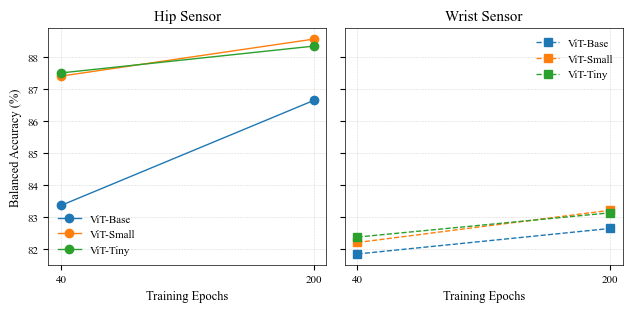

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data: Epochs and accuracies
epochs = np.array([40, 200])

# Hip and Wrist results
hip_acc = {
    "ViT-Base": [83.36, 86.65],
    "ViT-Small": [87.41, 88.57],
    "ViT-Tiny": [87.51, 88.35]
}

wrist_acc = {
    "ViT-Base": [81.84, 82.64],
    "ViT-Small": [82.20, 83.21],
    "ViT-Tiny": [82.37, 83.13]
}

# Style for medical journal
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "legend.frameon": False
})

fig, axes = plt.subplots(1, 2, figsize=(6.4, 3.2), sharey=True)  # two plots side by side

# --- Hip Plot ---
ax = axes[0]
for model, acc in hip_acc.items():
    ax.plot(epochs, acc, marker='o', linestyle='-', label=model)
ax.set_title("Hip Sensor", pad=6)
ax.set_xlabel("Training Epochs")
ax.set_ylabel("Balanced Accuracy (%)")
ax.set_xticks(epochs)
ax.grid(axis='both', linestyle='--', linewidth=0.4, alpha=0.5)
ax.legend()

# --- Wrist Plot ---
ax = axes[1]
for model, acc in wrist_acc.items():
    ax.plot(epochs, acc, marker='s', linestyle='--', label=model)
ax.set_title("Wrist Sensor", pad=6)
ax.set_xlabel("Training Epochs")
ax.set_xticks(epochs)
ax.grid(axis='both', linestyle='--', linewidth=0.4, alpha=0.5)
ax.legend()

# Save as high-resolution PDF
plt.tight_layout()
plt.savefig("epochs_vs_performance_split.pdf", format='pdf', dpi=600, bbox_inches='tight')

plt.show()



## Data augmentation illustration

In [ ]:
import numpy as np
csv_path = '/Users/leo/Desktop/DeepPostures_MAE/MoCA/assest/hip_sample.csv'
# load csv
data = np.loadtxt(csv_path, delimiter=',', skiprows=0)
print(data.shape)  # (41264, 43) -> 42 channels +

(4200, 3)


In [ ]:
# path = '/niddk-data-central/iWatch/pre_processed_long_seg/H/10s_val.h5'

# import h5py
# import numpy as np
# with h5py.File(path, 'r') as f:
#     print(f.keys())
#     x = f['x'][:]  # shape: (N, 42, 100, 3)
#     print(x.shape)



<KeysViewHDF5 ['subject_id', 'timestamp', 'x', 'y']>
(9401, 42, 100, 3)


(4200, 3)


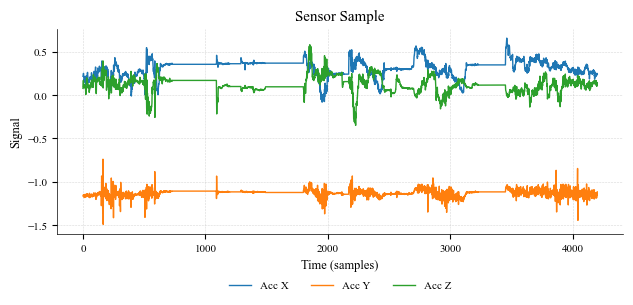

In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


sample = data#x[0].reshape(-1, 3)
print(sample.shape)
# Generate the plot
fig, ax = plot_nature_style(sample)
plt.show()


(4200, 3)

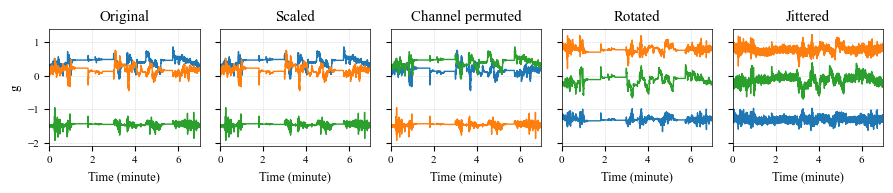

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from util.datasets import scaling, jittering, channel_permute, rotation_axis

# Assume sample shape is (T, C), e.g. (time, channels)
# Apply transformations step by step
scaling_sample = scaling(sample)
channel_permute_sample = channel_permute(scaling_sample)
rotation_axis_sample = rotation_axis(channel_permute_sample)
final_sample = jittering(rotation_axis_sample)  # jitter again for easy visual

# Collect samples and titles
samples = [sample, scaling_sample, channel_permute_sample, rotation_axis_sample, final_sample]
titles = ["Original", "Scaled", "Channel permuted", "Rotated", "Jittered"]

# --- Nature / medical journal style ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIX Two Text", "Times"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "legend.frameon": False
})

# Create 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(9.0, 2.0), sharey=True)

# Convert to minutes (10 Hz -> 600 samples per minute)
time = np.arange(sample.shape[0]) / 600.0
colors = ["tab:blue", "tab:green", "tab:orange"]

for ax, data, title in zip(axes, samples, titles):
    for i in range(data.shape[1]):
        ax.plot(time, data[:, i], color=colors[i])
    ax.set_title(title, pad=6)
    ax.set_xlabel("Time (minute)")
    ax.set_xlim(0, 7)  # enforce 7 minutes
    ax.grid(axis='both', linestyle='--', linewidth=0.4, alpha=0.5)

axes[0].set_ylabel("g")  # only left plot has y-label

plt.tight_layout()
plt.savefig("augment_steps.pdf", format="pdf", dpi=600, bbox_inches="tight")
plt.show()


## Find model architecture.

In [5]:
import os
import sys
path = '/Users/leo/Desktop/DeepPostures_MAE'
print('Adding path to sys.path:', path)
sys.path.append(path)

from MSSE_2021_pt.model import CNNBiLSTMModel

model = CNNBiLSTMModel(2,42,2)

x = torch.randn(42,1,100,3)  # adjust shape to match your model’s expected input
out = model(x)
print(out.shape)

Adding path to sys.path: /Users/leo/Desktop/DeepPostures_MAE
torch.Size([42, 1, 100, 3])
torch.Size([42, 64, 50, 3])
torch.Size([42, 128, 25, 3])
torch.Size([42, 256, 13, 3])
torch.Size([42, 512, 7, 3])
torch.Size([42, 512, 4, 3])
torch.Size([42, 6144])
torch.Size([42, 512])
torch.Size([1, 42])


In [34]:
print(model)

CNNBiLSTMModel(
  (cnn_model): CNNModel(
    (conv1): Conv2dSame(1, 64, kernel_size=(5, 3), stride=(2, 1))
    (conv2): Conv2dSame(64, 128, kernel_size=(5, 1), stride=(2, 1))
    (conv3): Conv2dSame(128, 256, kernel_size=(5, 1), stride=(2, 1))
    (conv4): Conv2dSame(256, 512, kernel_size=(5, 1), stride=(2, 1))
    (conv5): Conv2dSame(512, 512, kernel_size=(5, 1), stride=(2, 1))
    (fc): Linear(in_features=6144, out_features=512, bias=True)
  )
  (bil_lstm): LSTM(512, 128, batch_first=True, bidirectional=True)
  (fc_bilstm): Linear(in_features=256, out_features=1, bias=True)
)


In [44]:
from models_mae import MaskedAutoencoderViT, ClassiferHeadWrapper

base_model = MaskedAutoencoderViT(img_size=[3,4200],
                        patch_size=[1,100],
                        patch_emb='sundial',
                        use_rope = False,
                        learnable_pos_embed=True,
                        embed_dim=384,
                        depth=12,
                        num_heads=6)
model = ClassiferHeadWrapper(base_model, num_classes=2)

number of patches 126


In [45]:
print(model)

ClassiferHeadWrapper(
  (backbone): MaskedAutoencoderViT(
    (patch_embed): SundialPatchEmbedding(
      (dropout): Dropout(p=0.1, inplace=False)
      (hidden_layer): Linear(in_features=200, out_features=1536, bias=True)
      (act): SiLU()
      (output_layer): Linear(in_features=1536, out_features=384, bias=True)
      (residual_layer): Linear(in_features=200, out_features=384, bias=True)
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=384, out_features=1152, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=384, out_features=384, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True